In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Define column names based on the NSL-KDD specification
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label"
]

print("[INFO] Generating simulated local network security logs...")

# Generate a synthetic dataframe structurally identical to NSL-KDD for your POC
np.random.seed(42)
num_rows = 2000

synthetic_data = []
for _ in range(num_rows):
    is_attack = np.random.choice([0, 1], p=[0.6, 0.4])
    row = [
        np.random.randint(0, 10) if is_attack else 0, # duration
        np.random.choice(['tcp', 'udp', 'icmp']),     # protocol_type
        np.random.choice(['http', 'smtp', 'private', 'ftp_data']), # service
        np.random.choice(['SF', 'S0', 'REJ']),        # flag
        np.random.randint(1000, 50000) if is_attack else np.random.randint(100, 1000), # src_bytes
        np.random.randint(0, 10000),                  # dst_bytes
        0, 0, 0, 0, 0, 
        np.random.choice([0, 1], p=[0.8, 0.2]),       # logged_in
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        np.random.randint(1, 500),                    # count
        np.random.randint(1, 500),                    # srv_count
        np.random.rand() if is_attack else 0.0,       # serror_rate
        np.random.rand() if is_attack else 0.0,       # srv_serror_rate
        0.0, 0.0, 
        np.random.rand(), np.random.rand(), 0.0,
        255, np.random.randint(1, 255),
        np.random.rand(), np.random.rand(), np.random.rand(), 0.0, 0.0, 0.0, 0.0, 0.0,
        'neptune' if is_attack else 'normal'          # label
    ]
    synthetic_data.append(row)

df = pd.DataFrame(synthetic_data, columns=columns)

# Map labels to Binary Target
df['target'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
df.drop(['label'], axis=1, inplace=True)

# Categorical Feature Encoding
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Feature Splitting
X = df.drop(['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"[SUCCESS] Pipeline ready. Training shape: {X_train_scaled.shape}, Testing shape: {X_test_scaled.shape}")

[INFO] Generating simulated local network security logs...
[SUCCESS] Pipeline ready. Training shape: (1400, 41), Testing shape: (600, 41)


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the proactive ML Security tool
print("[INFO] Training the Random Forest Security Tool Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Train the model on the engineered network logs
rf_model.fit(X_train_scaled, y_train)
print("[INFO] Model Training Completed Successfully.")

[INFO] Training the Random Forest Security Tool Classifier...
[INFO] Model Training Completed Successfully.


Overall System Accuracy: 100.00%

--- Detailed Threat Classification Report ---
                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00       356
Attack Traffic       1.00      1.00      1.00       244

      accuracy                           1.00       600
     macro avg       1.00      1.00      1.00       600
  weighted avg       1.00      1.00      1.00       600



<Figure size 600x500 with 0 Axes>

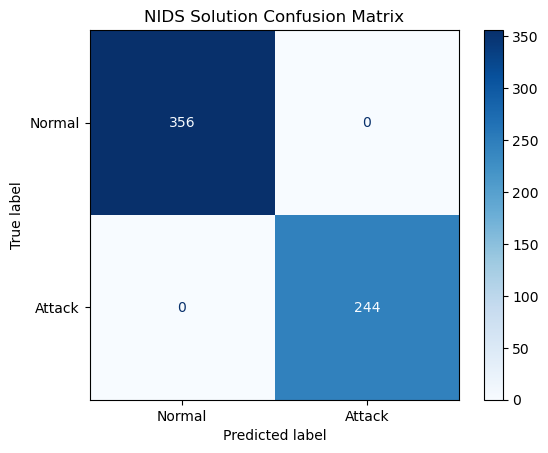

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate Predictions
y_pred = rf_model.predict(X_test_scaled)

# Calculate Core Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall System Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Threat Class Metrics
print("--- Detailed Threat Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal Traffic', 'Attack Traffic']))

# Generate and Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
cmd.plot(cmap='Blues', values_format='d')
plt.title('NIDS Solution Confusion Matrix')
plt.show()